# Assignment 5
## Data Analysis and Visualization

These assignments are related to visualization with **MathPlotLib** and **Seaborn** libraries.
* [Matplotlib](https://matplotlib.org/)
* [seaborn](https://seaborn.pydata.org/)

In these assignments, you must program some new code to get as an output figure given in assignment.
* Read the related course material before doing the assignments from the
[Topic 5. Visualization](https://ttc8040.pages.labranet.jamk.fi/da_vi_material/lectures/topic5_visualize.nbconvert/).

In [1]:
# Write your information here!
student_name = 'Jayani Kothalawala'
student_id = 'AD9680'

## Assignment 05-01. Visualizing Weather Data

Visualize weather data loaded from the [Finnish Meteorological Institute's WFS interface](https://en.ilmatieteenlaitos.fi/download-observations) using a `DataFrame`. Before plotting the data, you need to process it as follows:
* Load the data into a `DataFrame` from the file `'data/saatiedot.csv'`, considering that ',' is the column separator and '.' is the decimal separator.
* The first column (or index) of the data contains the time in the format **year-month-day hours:minutes:seconds**.
* Create a new `DataFrame` column `'time, s'` indicating the amount of time in seconds from the first measurement onwards.
* Add a new column `'Air temperature, degC'` to the `DataFrame`.
* Print the first five rows of your processed `DataFrame`.

After processing the data, create an x-y plot as follows:
* Use the column `'time, s'` on the horizontal axis and the column `'Air temperature, degC'` on the vertical axis.
* Mark data points with red dots.
* Provide a legend for the red dots, labeled as `'Air temperature'`.
* Use `'time, s'` for the x-axis title and `'Air temperature $^{o}C$'` for the y-axis title.
* Use [TeX syntax](https://en.wikipedia.org/wiki/TeX) to denote the physical unit in the y-axis title.
* Add a grid with a _black dashed line_.

**The final result should look like the following image:**

![h5.1](./img/h5_t1.png)

   time,s  Air temperature, degC  Wind speed, m/s  Gust speed, m/s  \
0     0.0                    6.5              2.3              4.3   
1   600.0                    6.2              2.5              3.9   
2  1200.0                    5.7              2.3              3.5   
3  1800.0                    5.7              2.8              4.0   
4  2400.0                    5.7              3.1              4.2   

   Wind direction, deg  Relative humidity, %  Dew-point temperature, degC  \
0                187.0                  79.0                          3.1   
1                180.0                  80.0                          3.0   
2                173.0                  81.0                          2.8   
3                164.0                  81.0                          2.7   
4                164.0                  83.0                          2.9   

   Snow depth, cm  Pressure (msl), hPa  Horizontal visibility, m  \
0             NaN               1011.3          

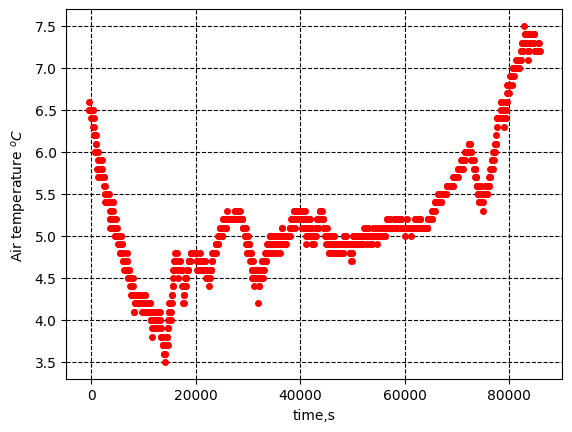

In [41]:
# TODO: Implementation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/saatiedot.csv",sep=",",decimal=".")
df.rename(columns={df.columns[0]: "time,s"}, inplace=True)
df["time,s"] = pd.to_datetime(df.iloc[:, 0], errors="coerce")
df["time,s"] = (df["time,s"] - df["time,s"].iloc[0]).dt.total_seconds()
df.head(5)
print(df.head(5))

plt.plot(df["time,s"],df["Air temperature, degC"], 'ro', markersize=4)
plt.xlabel("time,s")
plt.ylabel("Air temperature $^{o}C$")
plt.grid(color = 'black', linestyle = '--')
plt.show()

## Assignment 05-02. Premier League Standings

Visualize selected Premier League football teams' home and away wins in the same bar chart. Before plotting the data, you need to process it as follows:
* Load the data into a `DataFrame` from the given url address (`"data/england-premier-league-teams-2018-to-2019-stats.csv"`).
* Add new columns `common_name`, `wins_home` (home wins), and `wins_away` (away wins) to the DataFrame.
* Select the following teams from the DataFrame (`common_name` column): `'Arsenal', 'Tottenham Hotspur', 'Manchester City', 'Manchester United', 'Chelsea', 'Liverpool', 'Everton'`
* Shorten the team names for the chart by creating a new column `short_name` with the following names: `'Arsenal', 'Tottenham', 'ManCity', 'ManU', 'Chelsea', 'Liverpool', 'Everton'`
* Create a new DataFrame using the `df.melt(id_vars, var_name, value_name ...)` method with new columns `Win Type` and `Wins`
```
   short_name   Win Type  Wins
0     Arsenal  wins_home    14
::::::::::::::::::::::::::::::
7     Arsenal  wins_away     7
```

* After processing the data, create a bar chart on an (x, y)-plane, where the x-axis shows the team's shortened name and the y-axis shows both home wins (`wins_home`) and away wins (`wins_away`).
* Provide a legend for the bars (hint: `Legend`).
* Rotate the x-axis titles by 30 degrees (hint: `xticks`).
* Set a title for the chart.

**The final result should look like the following image:**

![h5.2](./img/h5_t2.png)

   short_name   Win Type  Wins
0     Arsenal  wins_home    14
1   Tottenham  wins_home    12
2     ManCity  wins_home    18
3     Everton  wins_home    10
4        ManU  wins_home    10
5   Liverpool  wins_home    17
6     Chelsea  wins_home    12
7     Arsenal  wins_away     7
8   Tottenham  wins_away    11
9     ManCity  wins_away    14
10    Everton  wins_away     5
11       ManU  wins_away     9
12  Liverpool  wins_away    13
13    Chelsea  wins_away     9


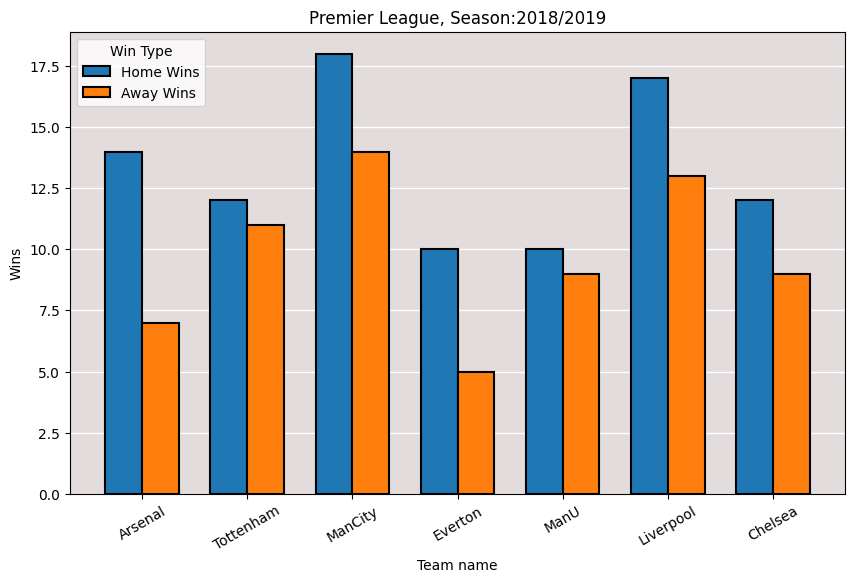

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
url = "data/england-premier-league-teams-2018-to-2019-stats.csv"
df = pd.read_csv(url)

# Normalize team names for matching
df["common_name"] = (
    df["team_name"]
      .str.replace(" FC", "", regex=False)
      .str.replace("AFC ", "", regex=False)
      .str.strip()
)

# Add wins columns
df["home wins"] = df["wins_home"]
df["away wins"] = df["wins_away"]

selected_teams = [
    "Arsenal", "Tottenham Hotspur", "Manchester City",
    "Manchester United", "Chelsea", "Liverpool", "Everton"
]

df = df[df["common_name"].isin(selected_teams)]

short_names = {
    "Arsenal": "Arsenal",
    "Tottenham Hotspur": "Tottenham",
    "Manchester City": "ManCity",
    "Manchester United": "ManU",
    "Chelsea": "Chelsea",
    "Liverpool": "Liverpool",
    "Everton": "Everton"
}

df["short_name"] = df["common_name"].map(short_names)

df_melted = df.melt(
    id_vars="short_name",
    value_vars=["wins_home", "wins_away"],
    var_name="Win Type",
    value_name="Wins"
)

print(df_melted)  # Now NOT empty

# ---- Plot ----
x = np.arange(len(df))     # X positions
w = 0.35                   # bar width

home = df["wins_home"]
away = df["wins_away"]

plt.figure(figsize=(10,6))

plt.bar(x - w/2, home, width=w, label="Home Wins", edgecolor="black", linewidth=1.5)
plt.bar(x + w/2, away, width=w, label="Away Wins", edgecolor="black", linewidth=1.5)


# Set light grey background
plt.gca().set_facecolor("#e2dadaf0")  # axes background

# Add white gridlines
plt.grid(color='white', linestyle='-', linewidth=1, axis='y', zorder=0)  # only horizontal

# Bring bars to front
plt.gca().set_axisbelow(True)  # gridlines stay behind bars

plt.xticks(x, df["short_name"], rotation=30)
plt.xlabel("Team name")
plt.ylabel("Wins")
plt.title("Premier League, Season:2018/2019")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), title="Win Type")

plt.show()


## Assignment 05-03. Premier League Standings

Visualize Premier League football data for selected teams, showing both home and away wins in the same bar chart. Before plotting the data, process it as follows:
* Load the data into a `DataFrame` from the file `"data/england-premier-league-teams-2018-to-2019-stats.csv"`.
* Add columns `team_name, common_name, season, wins, draws`, and `losses` to the `DataFrame`.
* Select the following teams (`common_name`): `'Arsenal', 'Tottenham Hotspur', 'Manchester City', 'Manchester United', 'Chelsea', 'Liverpool', 'Everton'`
* Shorten the team names for the chart by creating a new column `short_name` with the following names: `'Arsenal', 'Tottenham', 'ManCity', 'ManU', 'Chelsea', 'Liverpool', 'Everton'`
* Add a completely new column `points` to the `DataFrame` using the formula: `wins * 3 + draws` (0 points for losses).

After processing the data, create a bar chart on a transposed (x, y)-plane, where the y-axis shows the shortened team name, and the x-axis shows the points collected by the team.
* Try to rotate the y-axis titles by _30_ degrees (hint: `plt.yticks`).
* Add dynamically a title for the y-axis, including information about the season (`season`) and the number of matches played (`matches_played`) from the original `DataFrame`.
* Add a grid to the chart (hint: `grid`).

**The final result should look like the following image:**

![h5.3](./img/h5_t3.png)

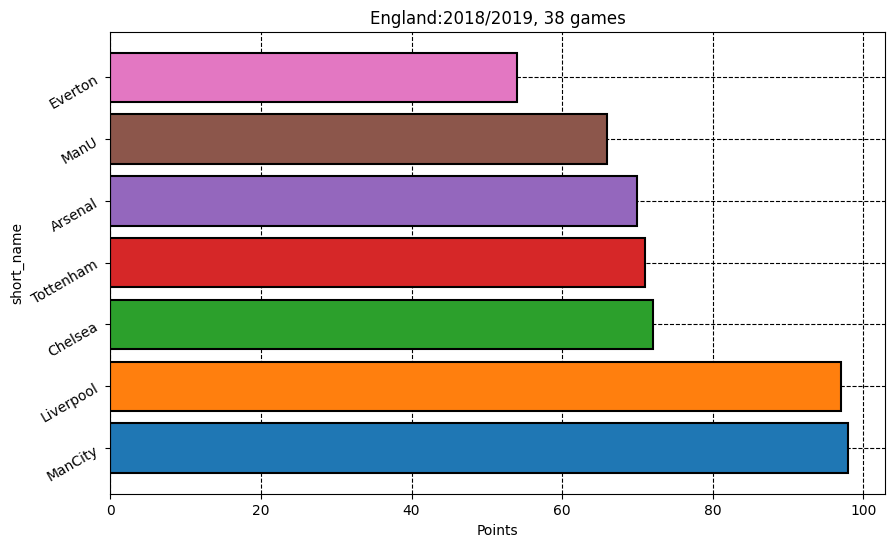

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df_full = pd.read_csv("data/england-premier-league-teams-2018-to-2019-stats.csv")

# Get season and matches dynamically from first row
season = df_full["season"].iloc[0]
matches_played = df_full["matches_played"].iloc[0]

# Keep only relevant columns for plotting
df = df_full[["team_name", "common_name", "wins", "draws", "losses"]]

# Select specific teams
teams = ['Arsenal', 'Tottenham Hotspur', 'Manchester City', 
         'Manchester United', 'Chelsea', 'Liverpool', 'Everton']
df = df[df["common_name"].isin(teams)]

# Short names for chart
short_names = {
    "Arsenal": "Arsenal",
    "Tottenham Hotspur": "Tottenham",
    "Manchester City": "ManCity",
    "Manchester United": "ManU",
    "Chelsea": "Chelsea",
    "Liverpool": "Liverpool",
    "Everton": "Everton"
}
df["short_name"] = df["common_name"].map(short_names)

# Add points column
df["points"] = df["wins"] * 3 + df["draws"]
df = df.sort_values(by="points", ascending=False)

# Assign different colors (one color per team)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]
# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(df["short_name"], df["points"], color=colors, edgecolor="black", linewidth=1.5)

# Rotate y-axis labels
plt.yticks(rotation=30)

# Dynamic y-axis label and title
plt.ylabel(f"short_name")
plt.xlabel("Points")
plt.title(f"England:{season}, {matches_played} games")

# Add grid
plt.grid(color = 'black', linestyle = '--')
plt.gca().set_axisbelow(True)
# Invert y-axis so highest points appear at top


plt.show()


## Assignment 05-04. Visualizing Car Data

Load the data into a `DataFrame` from the file: `data/autot.csv`.
Save only those rows in a new `DataFrame` where the car manufacturer (column `Mh`) has more than 50 cars. In the new `DataFrame`, replace the string `'DIESEL'` in column `Ft` with `'Diesel'` and `'PETROL'` with `'Petrol'`. If the string `'NG'` appears in column `Ft`, replace it with `'Natural gas'`.

The result of the visualization is an image similar to the one below, where you utilize the columns of your `DataFrame` for the car fuel type `Ft` and the car manufacturer `Mh`.

**The final result should look like the following image:**

![h5.4](./img/h5_t4.png)

C:\Users\jayani\AppData\Local\Temp\ipykernel_9244\1238534994.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Ft"] = (


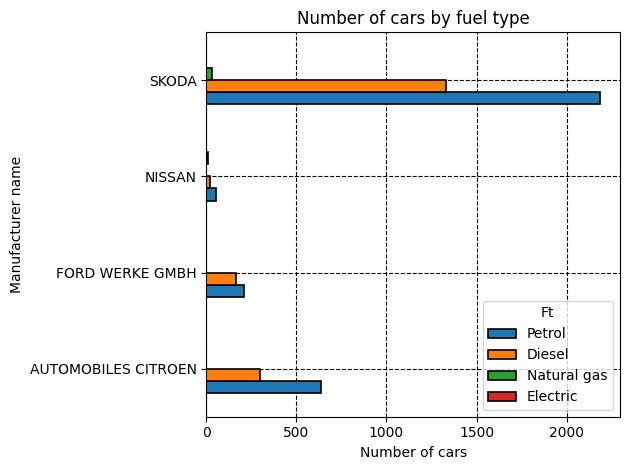

In [ ]:
# TODO: Implementation
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("data/autot.csv", on_bad_lines='skip', sep="\t")
df.fillna(0)
count = df["Mh"].value_counts()
df_filtered = df[df["Mh"].isin(count[count > 50].index)]

df_filtered["Ft"] = (
    df_filtered["Ft"]
        .replace("PETROL", "Petrol")
        .replace("DIESEL", "Diesel")
        .replace("NG", "Natural gas")
)
df_filtered

# ---- Plot ----
pivot = df_filtered.pivot_table(index="Mh", columns="Ft", aggfunc="size", fill_value=0)

# Define fuel order
fuel_order = ["Petrol", "Diesel", "Natural gas", "Electric"]
pivot = pivot.reindex(columns=[ft for ft in fuel_order if ft in pivot.columns])

# Define colors (matching your example)
colors = {
    "Petrol": "#1f77b4",        # blue
    "Diesel": "#ff7f0e",        # orange
    "Natural gas": "#2ca02c",   # green
    "Electric": "#d62728"       # red
}

# Plot
pivot.plot(
    kind="barh",
    edgecolor="black",
    linewidth=1.2,
    color=[colors[c] for c in pivot.columns]
)

plt.xlabel("Number of cars")
plt.ylabel("Manufacturer name")
plt.title("Number of cars by fuel type")

# Custom X ticks
plt.xticks([0, 500, 1000, 1500, 2000])

# Grid behind bars
plt.grid(color="black", linestyle="--")
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

## Assignment 05-05. Visualizing Car Data Part 2

Load the same data as in previous assignment into a `DataFrame` from the file: `data/autot.csv`

The result of the visualization is a _histogram_ similar to the one below, showing the distribution of $CO_2$ emissions (column `Enedc (g/km)`) in 100 different bins and a *cumulative histogram* of $CO_2$ emissions

**The final result should look like the following image:**

![h5.5](./img/h5_t5.png)


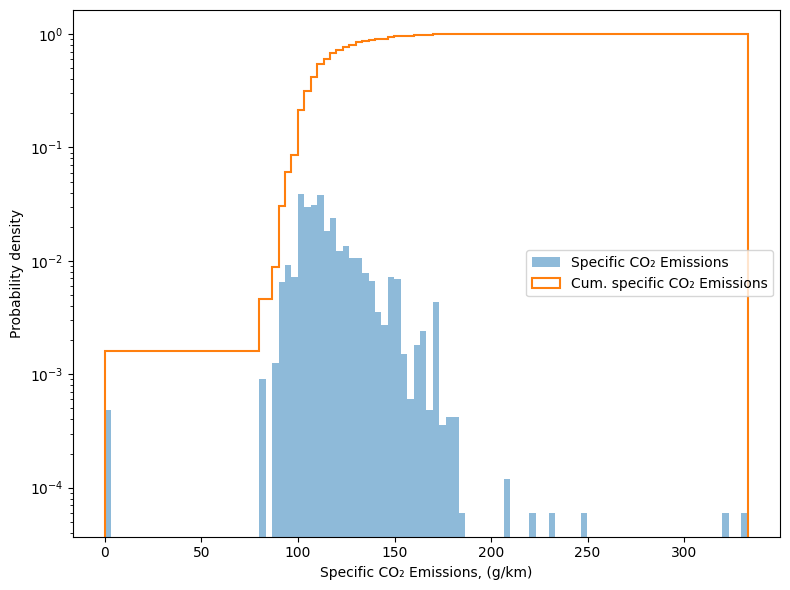

In [10]:
# TODO: Implementation
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("data/autot.csv", on_bad_lines='skip', sep="\t")

plt.figure(figsize=(8, 6))

# Normal histogram (probability density)
plt.hist(
    df["Enedc (g/km)"],
    bins=100,
    density=True,
    alpha=0.5,
    label="Specific CO₂ Emissions"
)

# Cumulative histogram (probability density)
plt.hist(
    df["Enedc (g/km)"],
    bins=100,
    density=True,
    cumulative=True,
    histtype="step",
    linewidth=1.5,
    label="Cum. specific CO₂ Emissions"
)

plt.yscale("log")   # << IMPORTANT: log scale exactly like image

plt.xlabel("Specific CO₂ Emissions, (g/km)")
plt.ylabel("Probability density")

plt.legend()
plt.tight_layout()
plt.show()